In [ ]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

  0%|          | 0/20 [00:00<?, ?it/s]

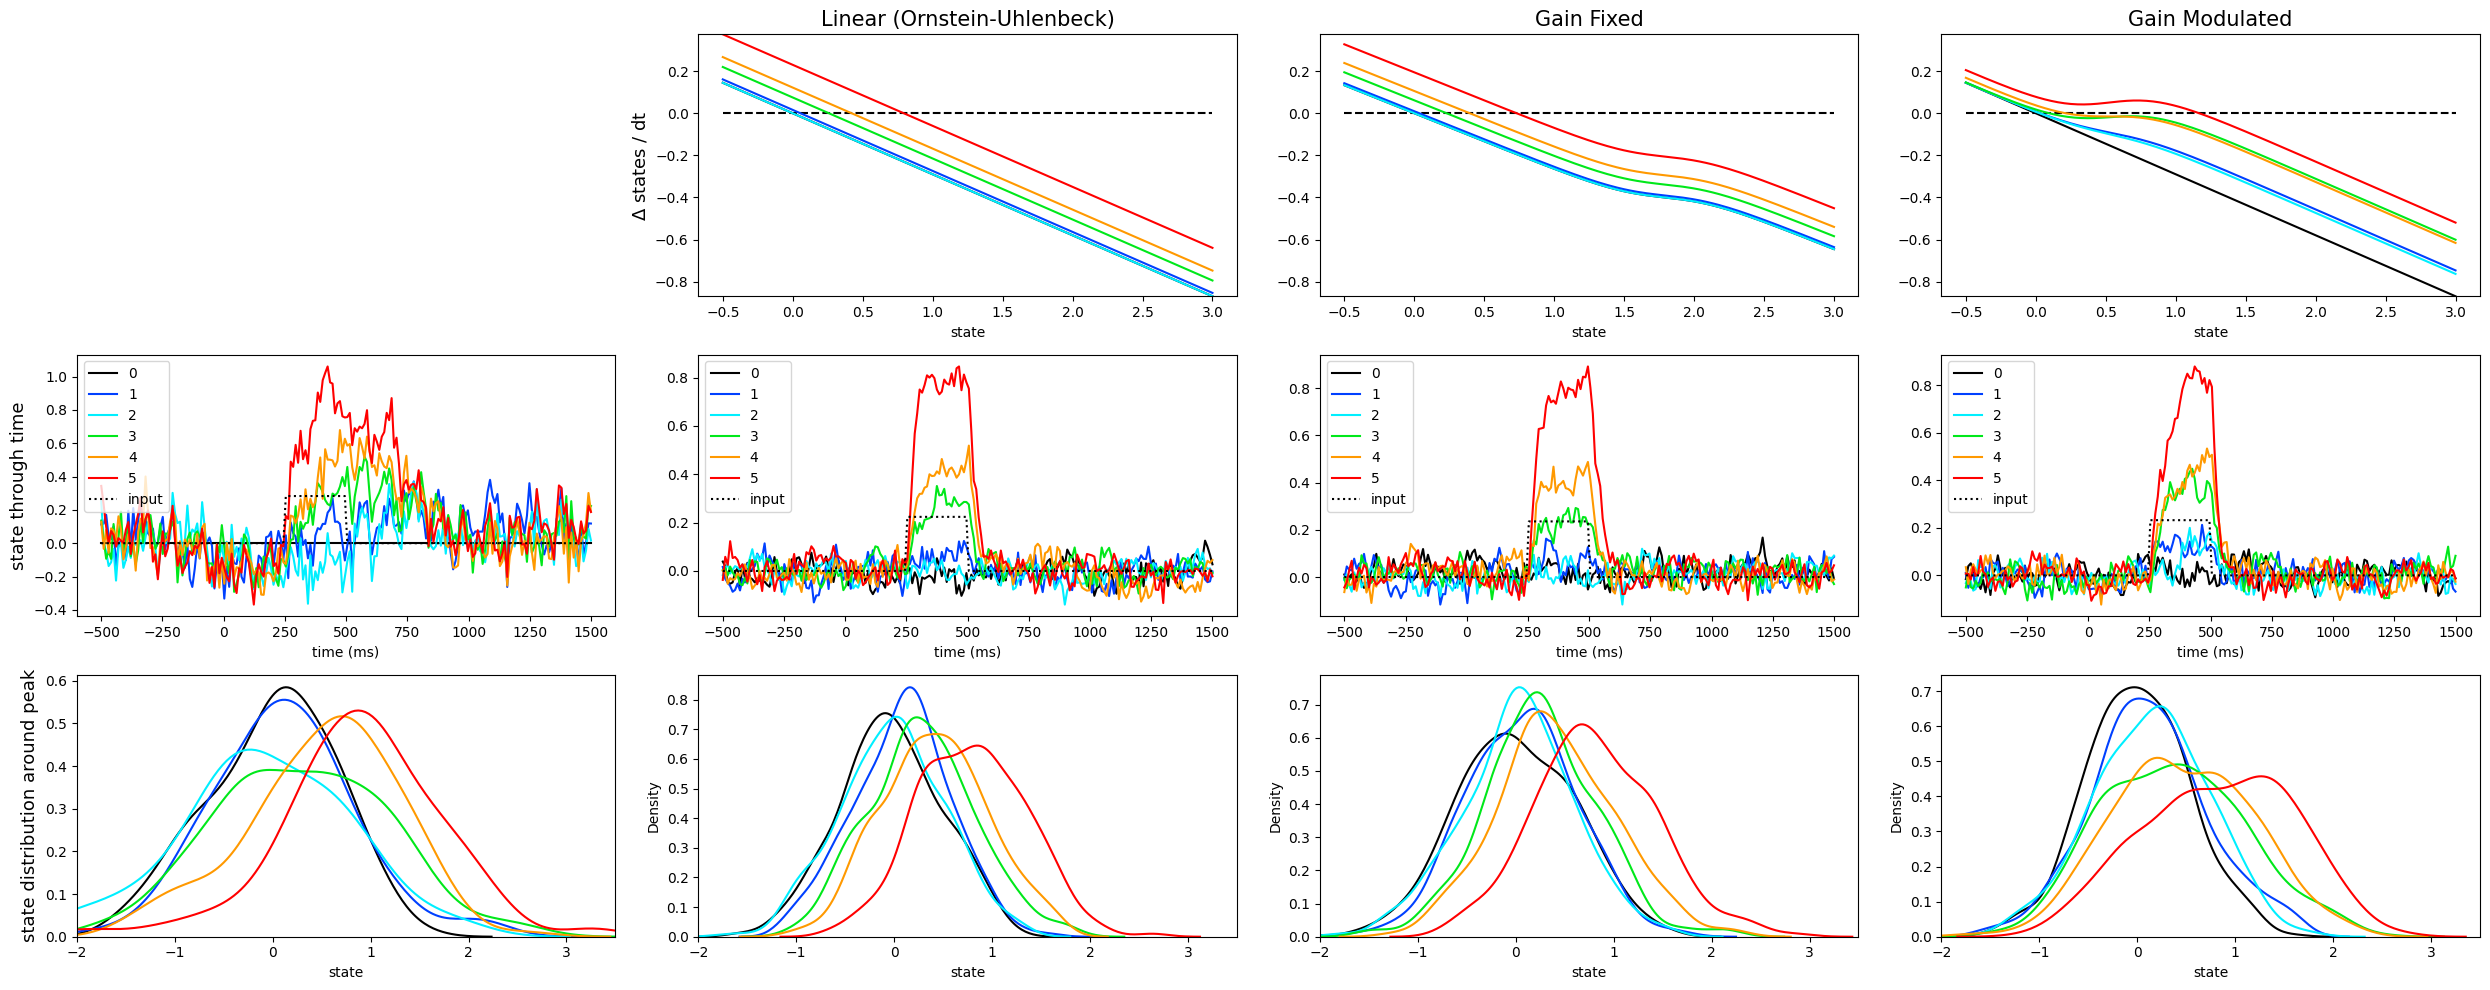

In [ ]:
task = 'Active'
file_path = cwd.parents[0] / f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
for part in tqdm(range(20)):
    
    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # Input definition (same for all categories & trials)
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

    # Re-organize to gather baseline windows together (= whole trials with no stim + baseline of trials with a stim)
    no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
    pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
    state_train[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
    input_train[0] = np.zeros_like(state_train[0])
    
    # ---- Fit StratifiedLinear ----
    linear = lead.fitting_tools.clever_fit_linear(state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=75, input_stop_index=100)
    linear.save_params(f'{file_path}/LinearModel_part{part}_params')

    # ---- Fit StratifiedGainModul  ----
    gainmodul = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=75, input_stop_index=100)
    gainmodul.save_params(f'{file_path}/GainModulatedModel_part{part}_params')

    # ---- Fit StratifiedNonLinear1  ----
    nonlinear = lead.fitting_tools.clever_fit_nonlinear1(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=75, input_stop_index=100)
    nonlinear.save_params(f'{file_path}/GainFixedModel_part{part}_params')

    # ---- Run Simulations from the fitted models  ----
    n_trials = 500
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(100)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    measures_linear = linear.measure_simulations(input_series = input_series)
    measures_nonlinear = nonlinear.measure_simulations(input_series = input_series)
    measures_gainmodul = gainmodul.measure_simulations(input_series = input_series)
    

    # ---- Plot Results  ----
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500)
        state_train = {cat: state_train[cat][:,:200] for cat in categories}
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(100)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}
    
    states = np.linspace(-0.5,3,150)
    conditions = [(0, 0), (1, 1), (1,2), (1,3), (1,4), (1,5)]
    if n_categories > len(conditions):
        conditions.append((1,6))
    labels = {cat: str(cat) for cat in range(n_categories)}
    
    plt.figure(figsize=(25, 10))
    
    # Define models and their corresponding measures
    models = [
        ("Linear (Ornstein-Uhlenbeck)", linear.core, measures_linear),
        ("Gain Fixed", nonlinear.core, measures_nonlinear),
        ("Gain Modulated", gainmodul.core, measures_gainmodul)
    ]
    
    
    # === TOP ROW: Δstate/dt plots ===
    for i, (title, model_func, _) in enumerate(models, start=1):
        plt.subplot2grid((9, 4), (0, i), rowspan=3)
        plt.plot([states[0], states[-1]], [0, 0], linestyle='--', color='black')
    
        for cond_ind, (input_value, signal_category) in enumerate(conditions):
            plt.plot(
                states,
                model_func(states, input_value * np.ones_like(states), signal_category) - states,
                color=colormap[cond_ind],
                label=labels[cond_ind]
            )
    
        plt.xlabel('state')
        if i == 1:
            plt.ylabel(r'$\Delta$ states / dt', fontsize=13)
        plt.ylim(linear.core(np.array([3]), np.array([0]), 0) - 3, linear.core(np.array([-0.5]), np.array([1]), 5) + 0.5)
        plt.title(title, fontsize=15)
    
    # === MIDDLE ROW: Time-series plots ===
    # Define all time-series datasets
    time_series_data = [
        ("Real Participant", state_train),
        ("Linear", measures_linear),
        ("Non-Linear", measures_nonlinear),
        ("Gain Modulation", measures_gainmodul)
    ]
    times = np.linspace(-500, 1500, 200)
    
    for i, (title, data_dict) in enumerate(time_series_data):
        plt.subplot2grid((9, 4), (3, i), rowspan=3)
    
        for cat in categories:
            mean_trace = (
                data_dict[cat][:, :200].mean(0)
                if title == "Real Participant"
                else data_dict[cat].mean(0)
            )
            plt.plot(times, mean_trace, color=colormap[cat], label=str(cat))
    
        ymin, ymax = plt.ylim()
        plt.plot(times, ymax * one_input / 4, color='black', linestyle=':', label='input')
    
        plt.xlabel('time (ms)')
        if i == 0:
            plt.ylabel('state through time', fontsize=13)
        # plt.title(title, fontsize=15)
        plt.legend(loc='upper left')
    
    # === BOTTOM ROW: KDE distributions ===
    t1, t2 = 90, 100
    xmin, xmax = -2, 3.5
    distribution_data = [
        ("Real Participant", state_train),
        ("Linear", measures_linear),
        ("Non-Linear", measures_nonlinear),
        ("Gain Modulation", measures_gainmodul)
    ]
    
    for i, (title, data_dict) in enumerate(distribution_data):
        plt.subplot2grid((9, 4), (6, i), rowspan=3)
    
        avgs = {cat: np.mean(data_dict[cat][:, t1:t2], -1).flatten() for cat in categories}
        for cat in categories:
            sns.kdeplot(data=avgs[cat], label=str(cat), color=colormap[cat])
    
        plt.xlim(xmin, xmax)
        plt.xlabel('state')
        if i == 0:
            plt.ylabel('state distribution around peak', fontsize=13)
        # plt.title(title, fontsize=15)
    
    plt.tight_layout()
    plt.savefig(f'{file_path}/AllModels_part{part}.png')
    plt.show()